In [11]:
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pathlib import Path
import os

In [28]:
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pathlib import Path
import os


class img_dataset(Dataset):
    def __init__(self, root_dir: str, img_size: int = 256):

        self.folder = Path(root_dir)
        allowed_exts = {".png", ".jpeg", ".jpg"}

        self.all_pths = [
            self.folder / name
            for name in os.listdir(self.folder)
            if Path(name).suffix.lower() in allowed_exts
        ]

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((256, 256)),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # -> [-1, 1]
        ])

    def __len__(self):
        return len(self.all_pths)

    def __getitem__(self, index):

        selected = self.all_pths[index]
        img = plt.imread(selected)
        img1, img2 = img[:, :img.shape[1]//2, :], img[:, img.shape[1]//2:, :]
        return self.transform(img2), self.transform(img1)
    

torch.Size([1, 3, 256, 256])
torch.Size([1, 3, 256, 256])


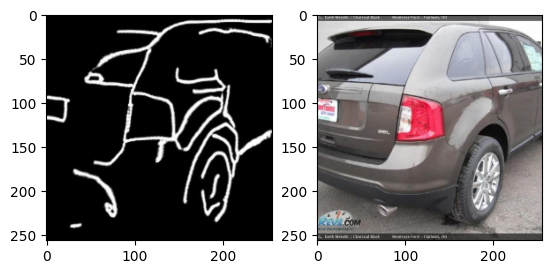

In [29]:
dataset = img_dataset("cars", 256)
img1, img2 = next(iter(DataLoader(dataset)))
print(img1.shape)
print(img2.shape)

img1 = img1[0].permute(1,2,0).cpu().detach().numpy()
img2 = img2[0].permute(1,2,0).cpu().detach().numpy()

img1 = (img1 + 1)/2
img2 = (img2 + 1)/2

fig, axes = plt.subplots(1, 2)

axes[0].imshow(img1)
axes[1].imshow(img2)